<a href="https://colab.research.google.com/github/suyashjaiswal235-jpg/iMAPP-Applied-DL/blob/main/Copy_of_Exercise_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4


In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
plt.rcParams.update({"image.cmap": "viridis"})

**Linear Regression**

The goal of this exercise is to explore a simple linear regression problem based on Portugese white wine.

The dataset is based on
Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. **Modeling wine preferences by data mining from physicochemical properties**. Published in Decision Support Systems, Elsevier, 47(4):547-553, 2009.



In [4]:
# The code snippet below is responsible for downloading the dataset
# - for example when running via Google Colab.
#
# You can also directly download the file using the link if you work
# with a local setup (the !wget command will work either way assuming
# you are on a unix-based machine and have wget installed)
!wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv

--2026-04-29 21:06:11--  https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘winequality-white.csv’

winequality-white.c     [ <=>                ] 258.23K  --.-KB/s    in 0.07s   

2026-04-29 21:06:11 (3.51 MB/s) - ‘winequality-white.csv’ saved [264426]



**Before we start**

The downloaded file contains data on 4989 wines. For each wine 11 features are recorded (column 0 to 10). The final columns contains the quality of the wine. This is what we want to predict. More information on the features and the quality measurement is provided in the original publication.

List of columns/features:
0. fixed acidity
1. volatile acidity
2. citric acid
3. residual sugar
4. chlorides
5. free sulfur dioxide
6. total sulfur dioxide
7. density
8. pH
9. sulphates
10. alcohol
11. quality



[file]: https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv

In [5]:
# Before working with the data,
# we download and prepare all features

# load all examples from the file
data = np.genfromtxt('winequality-white.csv',delimiter=";",skip_header=1)

print(f"{data.shape = }")

# Prepare for proper training
rng = np.random.default_rng(1234)
rng.shuffle(data)  # randomly sort examples

# take the first 3000 examples for training
# (remember array slicing from last week)
X_train = data[:3000, :11]  # all features except last column
y_train = data[:3000, 11]  # quality column

# and the remaining examples for testing
X_test = data[3000:, :11]  # all features except last column
y_test = data[3000:, 11]  # quality column

print("First example:")
print("Features:", X_train[0])
print("Quality:", y_train[0])

data.shape = (4898, 12)
First example:
Features: [6.8000e+00 1.9000e-01 7.1000e-01 1.7500e+01 4.2000e-02 2.1000e+01
 1.1400e+02 9.9784e-01 2.8500e+00 5.0000e-01 9.5000e+00]
Quality: 6.0


# Problems


* First we want to understand the data better. Plot (`plt.hist`) the distribution of each of the features for the training data as well as the 2D distribution (either `plt.scatter` or `plt.hist2d`) of each feature versus quality. Also calculate the correlation coefficient (`np.corrcoef`) for each feature with quality. Which feature by itself seems most predictive for the quality?

* Calculate the linear regression weights. Numpy provides functions for matrix multiplication (`np.matmul`), matrix transposition (`.T`) and matrix inversion (`np.linalg.inv`).

* Use the weights to predict the quality for the test dataset. How
does your predicted quality compare with the true quality of the test data? Calculate the correlation coefficient between predicted and true quality and draw a scatter plot.

**Homework Submission**

When you submit your exercise sheet, please alwasy do two things

1) Generate a PDF of your iPython notebook. Submit this PDF through Studium (Uppsala)/Moodle (Dortmund).

2) Provide a link to your google colab notebook so that we can directly execute and test your code. To do that click on "share", change access to "anyone with the link", copy the link and add it as a comment to your submission on Studium (Uppsala)/Moodle (Dortmund).

# Hints

Formally, we want to find weights $w_i$ that minimize:
$$
\sum_{j}\left(\sum_{i} X_{i j} w_{i}-y_{j}\right)^{2}
$$
The index $i$ denotes the different features (properties of the wines) while the index $j$ runs over the different wines. The matrix $X_{ij}$ contains the training data, $y_j$ is the 'true' quality for sample $j$. The weights can be found by taking the first derivative of the above expression with respect to the weights and setting it to zero (the standard strategy for finding an extremum), and solving the corresponding system of equations (for a detailed derivation, see [here](https://en.wikipedia.org/wiki/Ordinary_least_squares)). The result is:
$$
\overrightarrow{\mathbf{w}}=\left(\mathbf{X}^{T} \mathbf{X}\right)^{-1} \mathbf{X}^{T} \overrightarrow{\mathbf{y}}
$$

In the end, you should have as many components of $w_i$ as there are features in the data (i.e. eleven in this case).

You can use `.shape` to inspect the dimensions of numpy tensors.


### 1. Data Exploration
We will plot the histograms for each feature and scatter plots against the quality to understand the relationships.

Correlation of fixed acidity       : -0.1276
Correlation of volatile acidity    : -0.2069
Correlation of citric acid         : -0.0072
Correlation of residual sugar      : -0.0949
Correlation of chlorides           : -0.2099
Correlation of free sulfur dioxide : 0.0179
Correlation of total sulfur dioxide: -0.1720
Correlation of density             : -0.2999
Correlation of pH                  : 0.1038
Correlation of sulphates           : 0.0516
Correlation of alcohol             : 0.4285


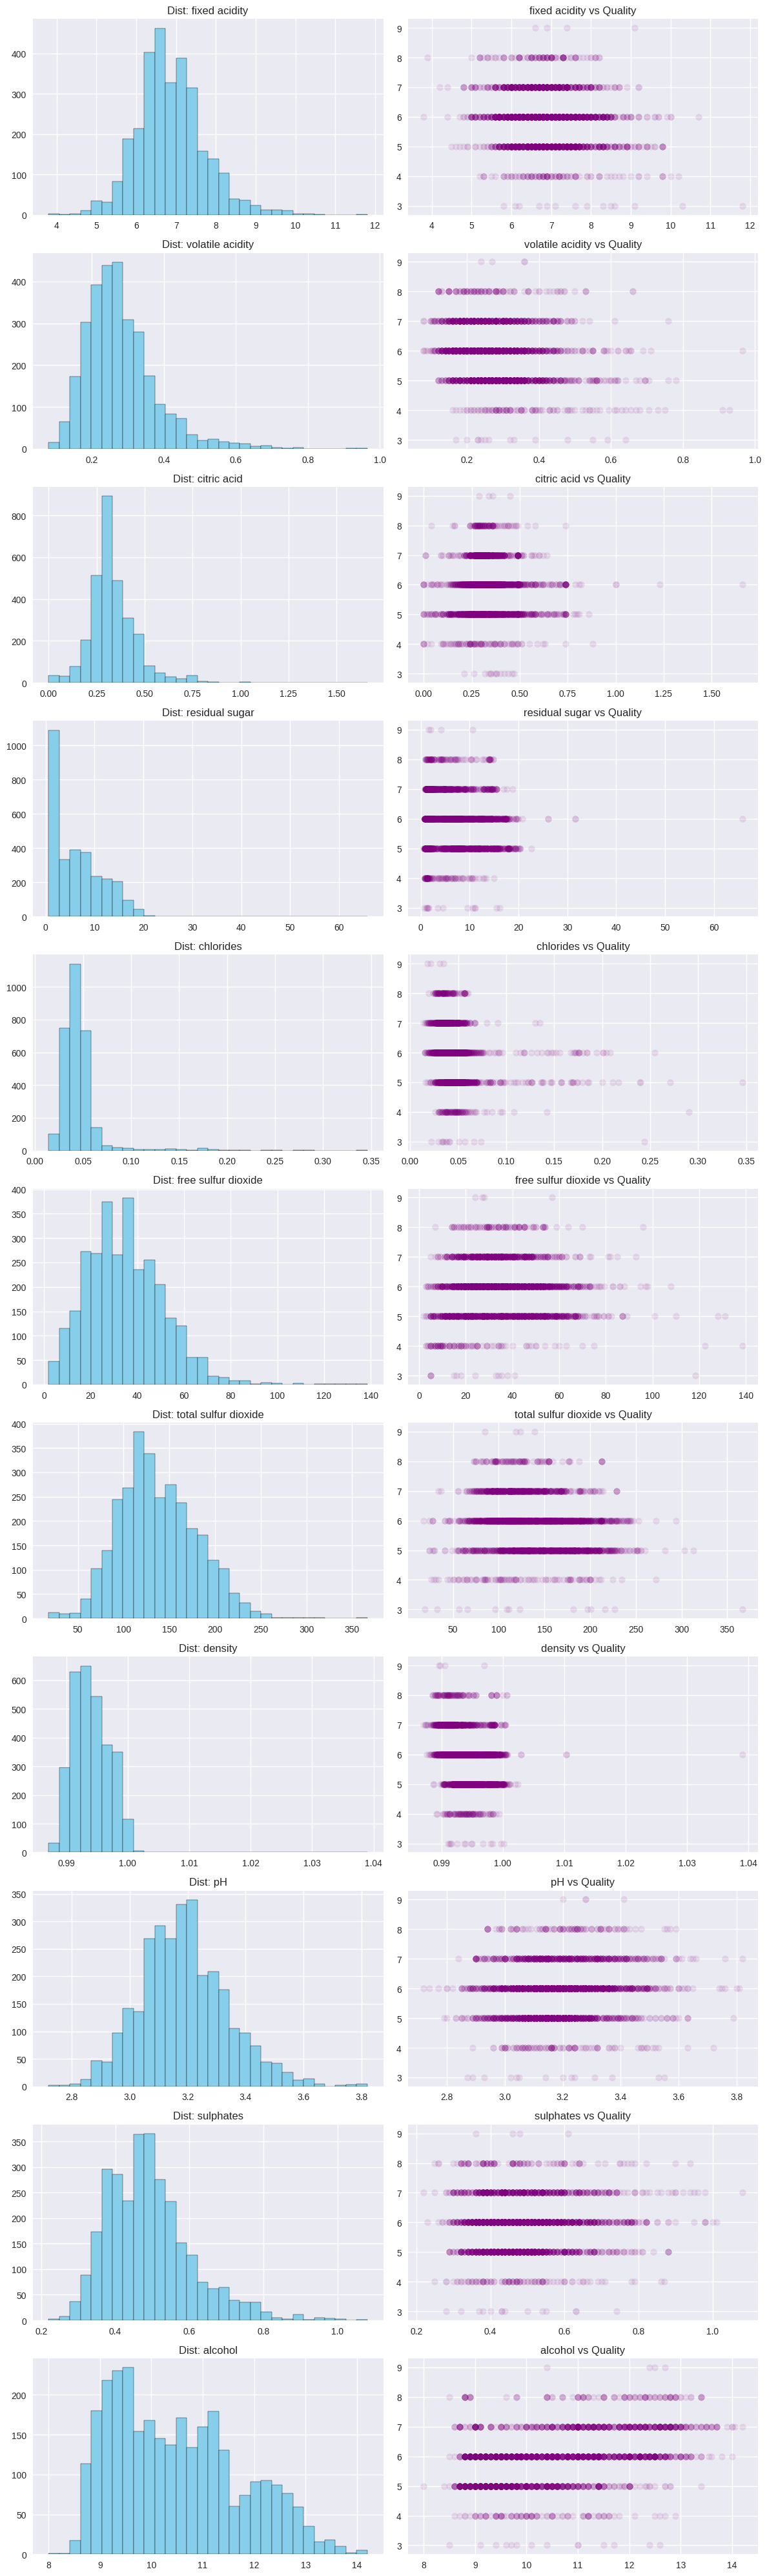


The most predictive feature is 'alcohol' with a correlation of 0.4285.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Feature names for labels
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

# Initialize plotting grid
fig, axes = plt.subplots(nrows=11, ncols=2, figsize=(12, 40))
correlations = []

for i in range(11):
    # 1D Histogram: Distribution of the feature
    axes[i, 0].hist(X_train[:, i], bins=30, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'Dist: {features[i]}')

    # 2D Scatter: Feature vs Quality
    # Using alpha to handle overlapping points
    axes[i, 1].scatter(X_train[:, i], y_train, alpha=0.1, color='purple')
    axes[i, 1].set_title(f'{features[i]} vs Quality')

    # Calculate Pearson correlation coefficient
    corr = np.corrcoef(X_train[:, i], y_train)[0, 1]
    correlations.append(corr)
    print(f"Correlation of {features[i]:<20}: {corr:.4f}")

plt.tight_layout()
plt.show()

# Identify the most predictive feature
most_predictive_idx = np.argmax(np.abs(correlations))
print(f"\nThe most predictive feature is '{features[most_predictive_idx]}' with a correlation of {correlations[most_predictive_idx]:.4f}.")

### 2. Linear Regression Weights
Using the formula: $\vec{\mathbf{w}}=(\mathbf{X}^{T} \mathbf{X})^{-1} \mathbf{X}^{T} \vec{\mathbf{y}}$.
Note: We typically add a bias term (intercept) by appending a column of ones to $X$.

In [7]:
# 1. Add bias term: We prepend a column of 1s to the training data
# This allows the model to have a non-zero intercept (the 'b' in y = mx + b)
X_train_bias = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1)

# 2. Apply the Normal Equation: w = (X^T * X)^-1 * X^T * y
# np.linalg.inv computes the matrix inverse
# .T computes the transpose
# @ or np.matmul performs matrix multiplication

XTX = X_train_bias.T @ X_train_bias
XTX_inv = np.linalg.inv(XTX)
XTy = X_train_bias.T @ y_train
weights = XTX_inv @ XTy

print("Weights calculated successfully.")
print(f"Number of weights: {len(weights)} (1 bias + 11 features)")
print("Weight values:", weights)

Weights calculated successfully.
Number of weights: 12 (1 bias + 11 features)
Weight values: [ 1.10236555e+02  1.97051124e-02 -1.97246956e+00  3.38869498e-03
  6.43013084e-02 -5.74013320e-01  5.22151568e-03 -5.99515349e-04
 -1.09453438e+02  5.28044869e-01  5.10629056e-01  2.33036086e-01]


### 3. Prediction and Evaluation
We apply the weights to the test set and compare the results.

Correlation on Test Set: 0.5292


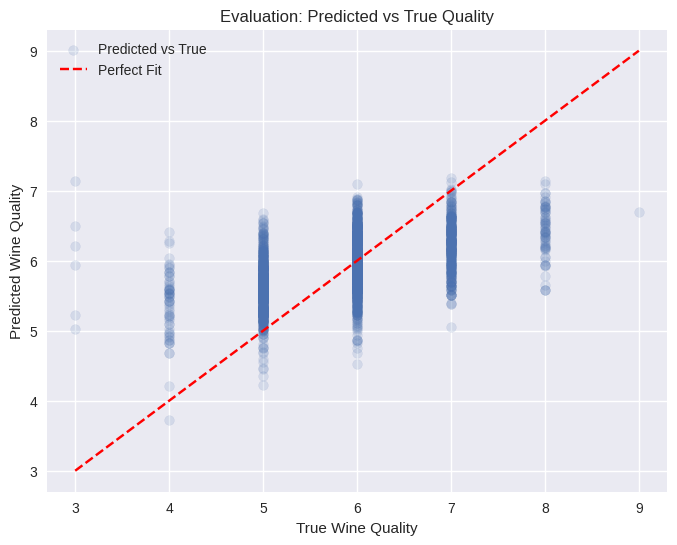

In [8]:
# Prepare test data by adding the bias column (ones)
X_test_bias = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)

# Generate predictions using the dot product of data and weights
y_pred = X_test_bias @ weights

# Evaluation: Correlation between predicted and actual values
test_corr = np.corrcoef(y_pred, y_test)[0, 1]
print(f"Correlation on Test Set: {test_corr:.4f}")

# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.15, label='Predicted vs True')
# Plot the identity line (perfect prediction)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
plt.xlabel('True Wine Quality')
plt.ylabel('Predicted Wine Quality')
plt.title('Evaluation: Predicted vs True Quality')
plt.legend()
plt.show()

### Code Explanation

1.  **Data Exploration**: We iterate through all 11 physicochemical features. For each, we create a histogram to see the distribution and a scatter plot against the `quality` target. The Pearson correlation coefficient measures the linear relationship; a higher absolute value suggests the feature is more predictive.
2.  **Linear Regression via Normal Equation**: We solve $\vec{\mathbf{w}}=(\mathbf{X}^{T} \mathbf{X})^{-1} \mathbf{X}^{T} \vec{\mathbf{y}}$. Before calculating, we add a column of ones to the feature matrix ($X$) to account for the intercept (bias). This allows the line to shift vertically rather than being forced through the origin.
3.  **Prediction**: We apply the learned weights to the test set using the dot product. We compare these predictions to the actual values using a scatter plot and a correlation score to measure accuracy.